the additive coupling was:

x2 = z2 + t(z1)

we now consider the coumpling affine:

x2 = e^{s(z1)} z2 + t(z1)

so we are rescaling z2 and than translate it

we are mantaning the x1=z1 so it's still invertible:

z1=x1
z2= (x2-t(z1)) e^{- s(z1)} = (x2-t(x1)) e^{- s(x1)}

in this way we have the invertibility and also the triangular jacobian,

but this time is det J is not 1: 

det J = e^{s(z1)}

so that:

log det J = s(z1)

In [54]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [55]:
def s(z1):
    return 0.5 * jnp.tanh(z1)

def t(z1):
    return z1**2

def forward(z):
    z1, z2 = z[..., 0], z[..., 1]
    x1 = z1
    x2 = z2 * jnp.exp(s(z1)) + t(z1)

    log_det = s(z1)

    x = jnp.stack([x1, x2], axis=-1)
    return x, log_det

def inverse(x):
    x1, x2 = x[..., 0], x[..., 1]

    z1 = x1
    z2 = (x2 - t(x1)) * jnp.exp(-s(x1))

    log_det = -s(x1)

    z = jnp.stack([z1, z2], axis=-1)
    return z, log_det


In [56]:
def log_pz(z):
    return -0.5 * jnp.sum(z**2, axis=-1) - 0.5 * jnp.log(2 * jnp.pi)

def log_px(x):
    z, log_det = inverse(x)
    return log_pz(z) + log_det

Sampling and Evaluating

we can aply the trasformation more than one time and see what appen to the distribution

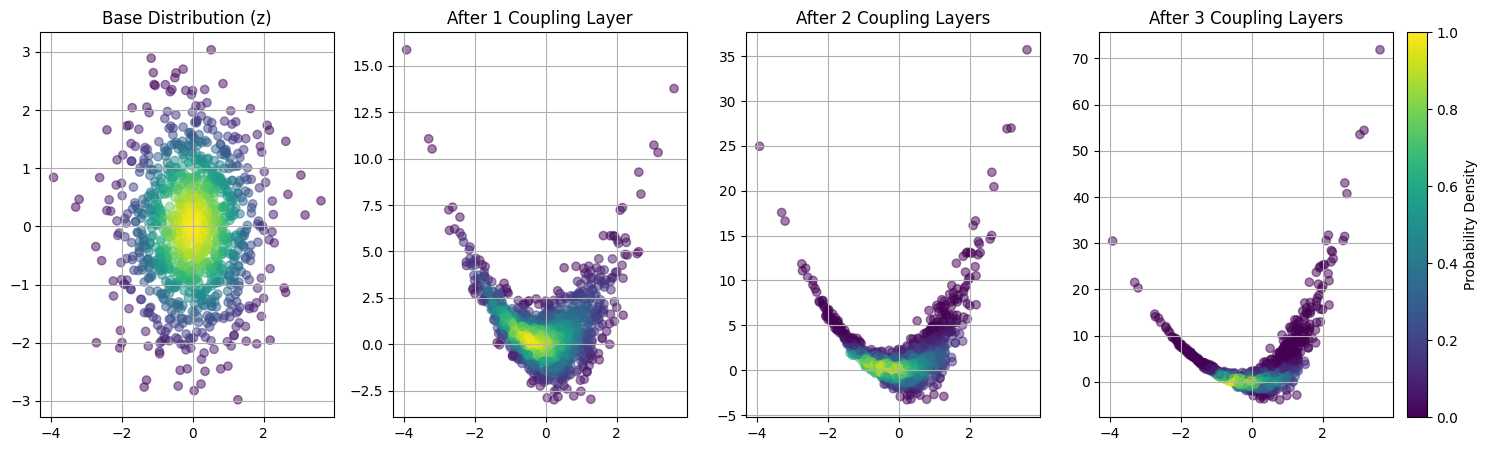

In [57]:
n_samples = 1000
key = jax.random.PRNGKey(0)
z_samples = jax.random.normal(key, (n_samples, 2))
log_prob_z = log_pz(z_samples)
prob_z = jnp.exp(log_prob_z)
x_samples1, _ = forward(z_samples)
log_prob_x1 = log_px(x_samples1)
prob_x1 = jnp.exp(log_prob_x1)
x_samples2, _ = forward(x_samples1)
log_prob_x2 = log_px(x_samples2)
prob_x2 = jnp.exp(log_prob_x2)
x_samples3, _ = forward(x_samples2)
log_prob_x3 = log_px(x_samples3)
prob_x3 = jnp.exp(log_prob_x3)

plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.scatter(z_samples[:, 0], z_samples[:, 1], alpha=0.5, c=prob_z, cmap='viridis')
plt.title('Base Distribution (z)')
plt.grid()
plt.subplot(1, 4, 2)
plt.scatter(x_samples1[:, 0], x_samples1[:, 1], alpha=0.5, c=prob_x1, cmap='viridis')
plt.title('After 1 Coupling Layer')
plt.grid()
plt.subplot(1, 4, 3)
plt.scatter(x_samples2[:, 0], x_samples2[:, 1], alpha=0.5, c=prob_x2, cmap='viridis')
plt.title('After 2 Coupling Layers')
plt.grid()
plt.subplot(1, 4, 4)
plt.scatter(x_samples3[:, 0], x_samples3[:, 1], alpha=0.5, c=prob_x3, cmap='viridis')
plt.title('After 3 Coupling Layers')
plt.grid()
# color bar for all subplots
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Probability Density')
plt.show()


Notice that the change has append only in the x2 values, because the trasfromation is changing only x2 and not x1.